In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import re
import sys
from pathlib import Path
import logging
from glob import glob

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [7]:
# Configuration
config = {
    'input_data': project_root / 'data' / 'input_data' / 'for_report' ,
    'output_plots': project_root / 'data' / 'output_data' / 'for_report'}

# Data preparation
Functions

In [33]:
def extract_station_id(filepath):
    """
    Extract station id from filenames like:
    porExtract_AB_05BB803_PC_CmdTotal.Merged.C.csv
    """
    fname = Path(filepath).name
    m = re.search(r'AB_([A-Z0-9]+)_', fname)
    return m.group(1) if m else fname

def read_alberta_timeseries(filepath, value_name):
    """
    Read Alberta web-export CSV with 22-line header.
    Returns columns: time, station_id, <value_name>
    """
    station_id = extract_station_id(filepath)

    df = pd.read_csv(filepath, skiprows=22)
    df.columns = [c.strip() for c in df.columns]

    # combine Date and Time
    df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
    df = df.dropna(subset=['time']).copy()

    # value column
    value_col = [c for c in df.columns if 'Value' in c][0]

    df = df[['time', value_col]].rename(columns={value_col: value_name})
    df['station_id'] = station_id

    return df[['time', 'station_id', value_name]]

def daily_aggregate(df, value_col, how='sum'):
    """
    Aggregate to daily data by station.
    """
    if how == 'sum':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .sum()
              .reset_index()
        )
    elif how == 'mean':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .mean()
              .reset_index()
        )
    elif how == 'last':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .last()
              .reset_index()
        )
    else:
        raise ValueError("how must be 'sum', 'mean', or 'last'")

    return out

def add_seasonal_year_oct_may(df, time_col='time'):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    out['month'] = out[time_col].dt.month
    out['year'] = out[time_col].dt.year

    out = out[out['month'].isin([10, 11, 12, 1, 2, 3, 4, 5])].copy()

    out['Seasonal_Year'] = out['year']
    out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'Seasonal_Year'] = (
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
    )

    return out

def combine_daily_swe_precip(folder, swe_pattern='*SW*.csv', precip_pattern='*PC*.csv',
                             swe_agg='last', precip_agg='sum', add_season_year=True):
    folder = Path(folder)

    swe_files = sorted(glob(str(folder / swe_pattern)))
    precip_files = sorted(glob(str(folder / precip_pattern)))

    if not swe_files:
        raise FileNotFoundError(f"No SWE files found with pattern: {swe_pattern}")
    if not precip_files:
        raise FileNotFoundError(f"No precip files found with pattern: {precip_pattern}")

    swe_all = pd.concat(
        [read_alberta_timeseries(f, 'SWE') for f in swe_files],
        ignore_index=True
    )
    precip_all = pd.concat(
        [read_alberta_timeseries(f, 'Precipitation') for f in precip_files],
        ignore_index=True
    )

    swe_daily = daily_aggregate(swe_all, 'SWE', how=swe_agg)
    precip_daily = daily_aggregate(precip_all, 'Precipitation', how=precip_agg)

    combined = pd.merge(
        swe_daily,
        precip_daily,
        on=['time', 'station_id'],
        how='outer'
    ).sort_values(['station_id', 'time']).reset_index(drop=True)

    if add_season_year:
        combined = add_seasonal_year_oct_may(combined, time_col='time')

    return combined

In [34]:
folder = config['input_data']

combined_daily_df = combine_daily_swe_precip(
    folder=folder,
    swe_agg='last',
    precip_agg='sum',
    add_season_year=True
)

display(combined_daily_df.head())
print(combined_daily_df.columns)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
0,05BB803,2025-03-10,320.0,11.9,3,2025,2024
1,05BB803,2025-03-11,322.0,1.4,3,2025,2024
2,05BB803,2025-03-12,324.0,2.1,3,2025,2024
3,05BB803,2025-03-13,342.0,18.3,3,2025,2024
4,05BB803,2025-03-14,347.0,5.0,3,2025,2024


Index(['station_id', 'time', 'SWE', 'Precipitation', 'month', 'year',
       'Seasonal_Year'],
      dtype='object')


In [35]:
# save combined_daily_df to output folder for later use
output_path = config['output_plots'] / 'combined_daily_swe_precip.csv'
combined_daily_df.to_csv(output_path, index=False)

In [52]:
# extract data for season year 2025
season_2025_df = combined_daily_df[combined_daily_df['Seasonal_Year'] == 2025].copy()
display(season_2025_df)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
205,05BB803,2025-10-01,1.0,2.8,10,2025,2025
206,05BB803,2025-10-02,4.0,0.6,10,2025,2025
207,05BB803,2025-10-03,1.0,0.0,10,2025,2025
208,05BB803,2025-10-04,4.0,3.0,10,2025,2025
209,05BB803,2025-10-05,8.0,0.0,10,2025,2025
...,...,...,...,...,...,...,...
2190,05CA805,2026-03-07,405.0,4.8,3,2026,2025
2191,05CA805,2026-03-08,419.0,16.6,3,2026,2025
2192,05CA805,2026-03-09,422.0,1.5,3,2026,2025
2193,05CA805,2026-03-10,424.0,1.5,3,2026,2025


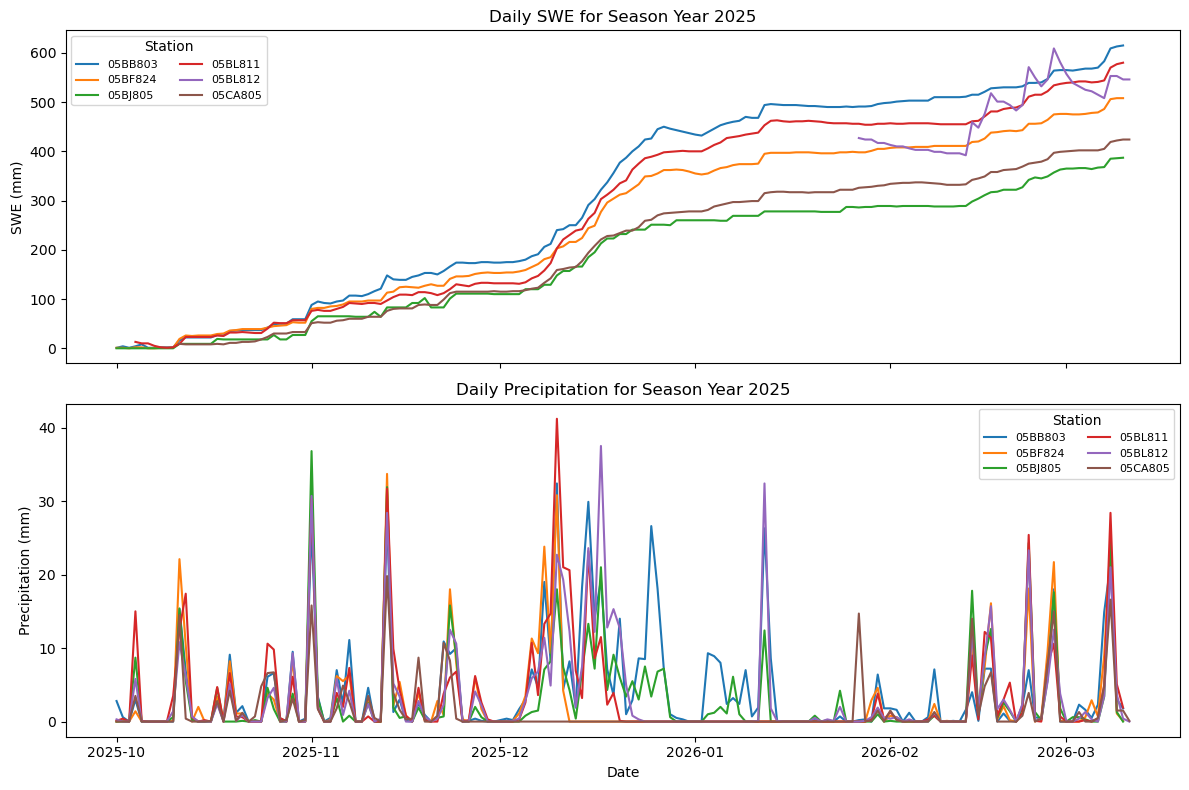

In [38]:
# plot daily SWE and precipitation for season 2025
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for station_id, group in season_2025_df.groupby('station_id'):
    axes[0].plot(group['time'], group['SWE'], label=station_id)
    axes[1].plot(group['time'], group['Precipitation'], label=station_id)

axes[0].set_title('Daily SWE for Season Year 2025')
axes[0].set_ylabel('SWE (mm)')
axes[0].legend(title='Station', ncol=2, fontsize=8)

axes[1].set_title('Daily Precipitation for Season Year 2025')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend(title='Station', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [69]:
# remove 05BL812
season_2025_df = season_2025_df[season_2025_df['station_id'] != '05BL812']
display(season_2025_df)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year,SWE_change
205,05BB803,2025-10-01,1.0,2.8,10,2025,2025,0.0
206,05BB803,2025-10-02,4.0,0.6,10,2025,2025,3.0
207,05BB803,2025-10-03,1.0,0.0,10,2025,2025,0.0
208,05BB803,2025-10-04,4.0,3.0,10,2025,2025,3.0
209,05BB803,2025-10-05,8.0,0.0,10,2025,2025,4.0
...,...,...,...,...,...,...,...,...
2190,05CA805,2026-03-07,405.0,4.8,3,2026,2025,3.0
2191,05CA805,2026-03-08,419.0,16.6,3,2026,2025,14.0
2192,05CA805,2026-03-09,422.0,1.5,3,2026,2025,3.0
2193,05CA805,2026-03-10,424.0,1.5,3,2026,2025,2.0


# Classification

In [70]:
# monthly
def calculate_running_oct_may_swe_precip(
    df,
    time_col='time',
    station_col='station_id',
    swe_col='SWE',
    precip_col='Precipitation',
    season_col='Seasonal_Year'
):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    # keep only Oct-May
    out = out[out[time_col].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])].copy()

    # if Seasonal_Year is not already there, create it
    if season_col not in out.columns:
        out['month'] = out[time_col].dt.month
        out['year'] = out[time_col].dt.year
        out[season_col] = out['year']
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), season_col] = (
            out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
        )

    out['month'] = out[time_col].dt.month

    # season month order: Oct=1, Nov=2, ..., May=8
    season_month_map = {10: 1, 11: 2, 12: 3, 1: 4, 2: 5, 3: 6, 4: 7, 5: 8}
    out['season_month_order'] = out['month'].map(season_month_map)

    results = []

    for (station_id, seasonal_year), group in out.groupby([station_col, season_col], dropna=False):
        group = group.sort_values(time_col).copy()

        for current_order in range(1, 9):
            subset = group[group['season_month_order'] <= current_order].copy()

            if subset.empty:
                continue

            current_month = [k for k, v in season_month_map.items() if v == current_order][0]

            results.append({
                station_col: station_id,
                season_col: seasonal_year,
                'month': current_month,
                'season_month_order': current_order,
                'mean_SWE': subset[swe_col].mean(skipna=True),
                'cumulative_P': subset[precip_col].sum(skipna=True)
            })

    result_df = pd.DataFrame(results).sort_values(
        [station_col, season_col, 'season_month_order']
    ).reset_index(drop=True)

    return result_df

In [ ]:
#calculate running monthly SWE and cumulative precipitation for season 2025
classification_df = calculate_running_oct_may_swe_precip(season_2025_df)

# caculate mean_SWE/Cum_P
classification_df['SWE_P_ratio'] = classification_df['mean_SWE'] / classification_df['cumulative_P']



display(classification_df.head(12))

,station_id,Seasonal_Year,month,season_month_order,mean_SWE,cumulative_P,SWE_P_ratio
0,05BB803,2025,10,1,25.548387,67.2,0.380184
1,05BB803,2025,11,2,79.885246,189.6,0.421336
2,05BB803,2025,12,3,157.510870,461.9,0.341006
3,05BB803,2025,1,4,238.487805,550.3,0.433378
4,05BB803,2025,2,5,290.947020,619.5,0.469648
5,05BB803,2025,3,6,309.031056,667.3,0.463107
6,05BB803,2025,4,7,309.031056,667.3,0.463107
7,05BB803,2025,5,8,309.031056,667.3,0.463107
8,05BF824,2025,10,1,25.225806,65.1,0.387493
9,05BF824,2025,11,2,70.295082,204.2,0.344246


In [65]:
def calculate_monthly_swe_precip_resample(
    df,
    time_col='time',
    station_col='station_id',
    swe_col='SWE',
    precip_col='Precipitation'
):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    monthly = (
        out.set_index(time_col)
           .groupby(station_col)
           .resample('M')
           .agg({
               swe_col: 'mean',
               precip_col: 'sum'
           })
           .rename(columns={
               swe_col: 'mean_SWE',
               precip_col: 'cumulative_P'
           })
           .reset_index()
    )

    monthly['year'] = monthly[time_col].dt.year
    monthly['month'] = monthly[time_col].dt.month

    if 'Seasonal_Year' in out.columns:
        monthly['Seasonal_Year'] = monthly[time_col].dt.year
        monthly.loc[monthly['month'].isin([1, 2, 3, 4, 5]), 'Seasonal_Year'] = (
            monthly.loc[monthly['month'].isin([1, 2, 3, 4, 5]), time_col].dt.year - 1
        )
        monthly.loc[monthly['month'].isin([10, 11, 12]), 'Seasonal_Year'] = (
            monthly.loc[monthly['month'].isin([10, 11, 12]), time_col].dt.year
        )

    return monthly

monthly_df = (
    season_2025_df
    .groupby(['station_id', 'Seasonal_Year', season_2025_df['time'].dt.month], dropna=False)
    .agg(
        mean_SWE=('SWE_change', 'mean'),
        cumulative_P=('Precipitation', 'sum')
    )
    .reset_index()
    .rename(columns={'time': 'month'})
)

display(monthly_df.head())

,station_id,Seasonal_Year,month,mean_SWE,cumulative_P
0,05BB803,2025,1,2.419355,88.4
1,05BB803,2025,2,2.392857,69.2
2,05BB803,2025,3,5.100000,47.8
3,05BB803,2025,10,2.225806,67.2
4,05BB803,2025,11,4.466667,122.4


# Calculate SWEI

In [45]:


def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id"]]
        .drop_duplicates("station_id")
        .set_index("station_id")
    )


def daily_to_monthly_swe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily SWE → monthly integrated SWE.
    Seasonal_Year is recomputed from time.
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["station_id", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            SWE_monthly=("SWE", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )

    return monthly



def rolling_integrated_swe_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated SWE within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_months}mo"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_months}mo"])



def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    # ranks with average ties
    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute SWEI for ONE Grid_id using calendar-month standardization.
    """
    out = df.copy()
    out["month"] = out["time"].dt.month

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for m in range(1, 13):
        idx = out["month"] == m
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue  # Near-normal (NN)

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out



def compute_swei(
    df: pd.DataFrame,
    window_months: int = 3
) -> pd.DataFrame:
    """
    End‑to‑end SWEI calculation with metadata preservation.
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily → monthly SWE
    monthly = daily_to_monthly_swe(df)

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season(monthly, window_months)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid(
                g,
                swe_col=f"SWE_{window_months}mo"
            )
        )
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei


def plot_seasonal_sswei_maps(
    swei_df,
    basin_gdf,
    config,
    window_label="3-month",
    swei_col="Avg_SWEI_3mo",
    start_year=1980,
    end_year=2024,
    month_order=(10, 11, 12, 1, 2, 3, 4, 5),
    month_names=None,
    classify_func=None,
    severity_colors=None,
    nrows=2,
    ncols=3,
    figsize=(20, 10),
    dpi=300
):
    """
    Plot seasonal SSWEI maps for each Seasonal_Year.

    Parameters
    ----------
    swei_df : pandas.DataFrame
        DataFrame containing SSWEI values with columns:
        ['Seasonal_Year', 'month', 'Elevation_Category', swei_col].
    basin_gdf : geopandas.GeoDataFrame
        Basin polygons with elevation categories column 'elev_class'.
    config : dict
        Configuration dictionary containing output directory path:
        config['SWEI_plots'].
    window_label : str
        Text label for SWEI window (e.g., '3-month', '6-month', '8-month').
    swei_col : str
        Column name containing SSWEI values.
    start_year, end_year : int
        Seasonal_Year range to plot (end_year is exclusive).
    month_order : iterable
        Ordered months for snow season (default Oct–May).
    month_names : dict
        Mapping of month number → month name.
    classify_func : callable
        Function that maps SSWEI → drought class.
    severity_colors : dict
        Mapping of drought class → color.
    nrows, ncols : int
        Subplot grid dimensions.
    figsize : tuple
        Figure size.
    dpi : int
        Output resolution.
    """

    if month_names is None:
        month_names = {
            1: "January", 2: "February", 3: "March", 4: "April",
            5: "May", 10: "October", 11: "November", 12: "December"
        }

    if classify_func is None or severity_colors is None:
        raise ValueError("Both classify_func and severity_colors must be provided.")

    for season_year in range(start_year, end_year):

        # Subset data for this season
        swei_year = swei_df[swei_df["Seasonal_Year"] == season_year]
        if swei_year.empty:
            continue

        # Determine months present and in correct order
        available_months = swei_year["month"].unique().tolist()
        months_year = [m for m in month_order if m in available_months]
        n_months = len(months_year)

        # Create subplot grid
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
        axes = axes.flatten()

        for idx, month in enumerate(months_year):
            ax = axes[idx]

            # Subset month data
            month_data = swei_year[swei_year["month"] == month]

            # Prepare elevation-band SSWEI table
            sswei_long = (
                month_data[["Elevation_Category", swei_col]]
                .rename(columns={swei_col: "SSWEI"})
            )

            # Merge with basin geometry
            basin_plot = basin_gdf.merge(
                sswei_long,
                left_on="elev_class",
                right_on="Elevation_Category",
                how="left"
            )

            # Classify SSWEI and assign colors
            basin_plot["Drought_Classification"] = (
                basin_plot["SSWEI"].apply(classify_func)
            )
            basin_plot["color"] = (
                basin_plot["Drought_Classification"]
                .map(severity_colors)
                .fillna("#dddddd")
            )

            # Plot
            basin_plot.plot(
                ax=ax,
                color=basin_plot["color"],
                edgecolor="black",
                linewidth=0.5
            )

            # Display year logic
            display_year = season_year if month >= 10 else season_year + 1

            ax.set_title(
                f"{month_names.get(month, str(month))} {display_year}",
                fontsize=12,
                fontweight="bold"
            )
            ax.axis("off")

        # Hide unused axes
        for j in range(n_months, len(axes)):
            axes[j].set_visible(False)

        # Figure title and legend
        fig.suptitle(
            f"{window_label} SSWEI Distribution across Bow River Basin "
            f"(Season {season_year})",
            fontsize=16,
            fontweight="bold",
            y=0.98
        )

        legend_handles = [
            mpatches.Patch(color=c, label=l)
            for l, c in severity_colors.items()
        ]
        fig.legend(
            handles=legend_handles,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            title="Drought Severity"
        )

        plt.tight_layout()

        # Save output
        out_file = (
            config["SWEI_plots"]
            / f"SSWEI_bow_basin_monthly_{window_label.replace(' ', '_')}_{season_year}.png"
        )
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        plt.close(fig)



In [48]:
# 1-month SWEI
swei_1mo = compute_swei(season_2025_df, window_months=1)
swei_1mo_output_dir = config['output_plots'] / 'swei_1mo'
swei_1mo_output_dir.mkdir(parents=True, exist_ok=True)
swei_1mo.to_csv(swei_1mo_output_dir / 'swei_1mo.csv', index=False)

display(swei_1mo.head())

,station_id,time,SWE_monthly,Seasonal_Year,SWE_1mo,month,Gringorten_p,SWEI
0,05BB803,2025-10-01,792.0,2025,792.0,10,0.5,0.0
1,05BB803,2025-11-01,4081.0,2025,4081.0,11,0.5,0.0
2,05BB803,2025-12-01,9618.0,2025,9618.0,12,0.5,0.0
3,05BB803,2026-01-01,14843.0,2025,14843.0,1,0.5,0.0
4,05BB803,2026-02-01,14599.0,2025,14599.0,2,0.5,0.0
